In [1]:
import pandas as pd

In [2]:
from sklearn.linear_model import LogisticRegression

In [3]:
from sklearn.model_selection import train_test_split

In [4]:
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("framingham.csv")

In [6]:
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [7]:
df.shape

(4238, 16)

In [8]:
df.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [10]:
df.drop(columns = ['education'])

,male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4233,1,50,1,1.0,0.0,0,1,0,313.0,179.0,92.0,25.97,66.0,86.0,1
4234,1,51,1,43.0,0.0,0,0,0,207.0,126.5,80.0,19.71,65.0,68.0,0
4235,0,48,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0


In [11]:
df.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [12]:
df = df[df['cigsPerDay'].notna()]

In [14]:
df["BPMeds"] = df["BPMeds"].fillna(0)

In [15]:
df.isnull().sum()

male                 0
age                  0
education          103
currentSmoker        0
cigsPerDay           0
BPMeds               0
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            384
TenYearCHD           0
dtype: int64

In [16]:
df.drop(columns = ['education'])

,male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4233,1,50,1,1.0,0.0,0,1,0,313.0,179.0,92.0,25.97,66.0,86.0,1
4234,1,51,1,43.0,0.0,0,0,0,207.0,126.5,80.0,19.71,65.0,68.0,0
4235,0,48,1,20.0,0.0,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0


In [17]:
df.isnull().sum()

male                 0
age                  0
education          103
currentSmoker        0
cigsPerDay           0
BPMeds               0
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            384
TenYearCHD           0
dtype: int64

In [18]:
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [19]:
df = df.drop(columns=['education'])

In [20]:
df.isnull().sum()

male                 0
age                  0
currentSmoker        0
cigsPerDay           0
BPMeds               0
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            384
TenYearCHD           0
dtype: int64

In [21]:
df.head()

,male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [22]:
df["heartRate"] = df["heartRate"].fillna(0)
df["totChol"] = df["totChol"].fillna(0)
df["BMI"] = df["BMI"].fillna(0)


In [23]:
df.isnull().sum()

male                 0
age                  0
currentSmoker        0
cigsPerDay           0
BPMeds               0
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol              0
sysBP                0
diaBP                0
BMI                  0
heartRate            0
glucose            384
TenYearCHD           0
dtype: int64

In [24]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')

In [25]:
df["glucose"] = imputer.fit_transform(df[["glucose"]])

In [26]:
df.isnull().sum()

male               0
age                0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64

In [30]:
##initialize

y = np.array(df["TenYearCHD"]) ## predicting this so ouput val 
df.drop(columns = "TenYearCHD" , inplace = True) # so remove from dataset 
X = np.array(df) # np array for input features

KeyError: 'TenYearCHD'

In [31]:
y

array([0, 0, 0, ..., 0, 0, 0], shape=(4209,))

In [32]:
X

array([[  1.        ,  39.        ,   0.        , ...,  26.97      ,
         80.        ,  77.        ],
       [  0.        ,  46.        ,   0.        , ...,  28.73      ,
         95.        ,  76.        ],
       [  1.        ,  48.        ,   1.        , ...,  25.34      ,
         75.        ,  70.        ],
       ...,
       [  0.        ,  48.        ,   1.        , ...,  22.        ,
         84.        ,  86.        ],
       [  0.        ,  44.        ,   1.        , ...,  19.16      ,
         86.        ,  81.94431373],
       [  0.        ,  52.        ,   0.        , ...,  21.47      ,
         80.        , 107.        ]], shape=(4209, 14))

In [33]:
X_scaled = StandardScaler().fit_transform(X)
X_scaled

array([[ 1.15406064e+00, -1.23362812e+00, -9.81403579e-01, ...,
         2.90350636e-01,  3.43938509e-01, -2.16090704e-01],
       [-8.66505595e-01, -4.17936895e-01, -9.81403579e-01, ...,
         6.88095147e-01,  1.58633225e+00, -2.59795597e-01],
       [ 1.15406064e+00, -1.84882259e-01,  1.01894880e+00, ...,
        -7.80150184e-02, -7.01927373e-02, -5.22024956e-01],
       ...,
       [-8.66505595e-01, -1.84882259e-01,  1.01894880e+00, ...,
        -8.32825624e-01,  6.75243506e-01,  1.77253336e-01],
       [-8.66505595e-01, -6.50991531e-01,  1.01894880e+00, ...,
        -1.47464063e+00,  8.40896005e-01, -6.21083889e-16],
       [-8.66505595e-01,  2.81227013e-01, -9.81403579e-01, ...,
        -9.52600959e-01,  3.43938509e-01,  1.09505609e+00]],
      shape=(4209, 14))

In [34]:
X_train , X_test , y_train,y_test = train_test_split(X_scaled, y , test_size = 0.25)

In [35]:
# MODEL CREATION 
model  = LogisticRegression()
model.fit(X_train , y_train)
y_pred = model.predict(X_test)

In [36]:
accuracy_score(y_test , y_pred) * 100

84.61538461538461

In [37]:
## MAKE CONFUSION MATRIX 

In [38]:
from sklearn.metrics import confusion_matrix , ConfusionMatrixDisplay

In [39]:
cf = confusion_matrix(y_test , y_pred)


<Figure size 800x600 with 0 Axes>

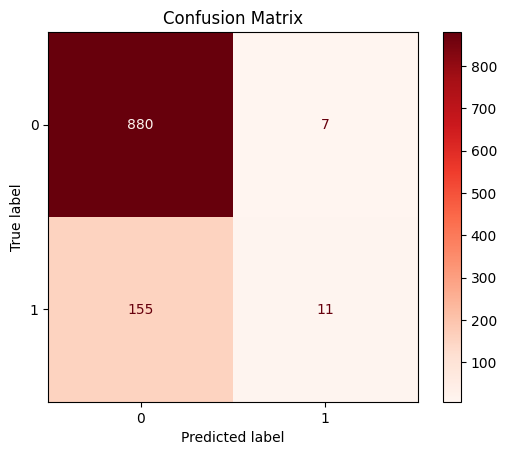

In [43]:
disp = ConfusionMatrixDisplay(cf , display_labels = ['0','1'])
plt.figure(figsize = (8,6))
disp.plot(cmap = plt.cm.Reds)
plt.title("Confusion Matrix")
plt.show()
                              